# Batch screening

## Sample

- total 32 measurements +/- OA


In [1]:
from importlib.metadata import version, metadata

In [2]:
lib_name = "imfcsoutputhandlerlib"
print(f"Running {metadata(lib_name)['Name']} v{version(lib_name)}")

Running imfcsoutputhandlerlib v1.0.1


In [3]:
from pathlib import Path
import os
import time
import datetime

from imfcsoutputhandlerlib.core.all_image import AllImage
from imfcsoutputhandlerlib.screener import ImfcsScreenerApp

### Set the input directory


In [4]:
DIRNAME = "input/input_mef-dii-oa-37c/2x2-overlap"
# DIRNAME = "input/input_mef-dii-oa-37c/XX"

current_dir = Path().resolve()
input_path = Path(os.path.join(current_dir.parent, DIRNAME))

### Choose whether to reload previous database (if so provide .pkl filename) or load from scratch


In [5]:
# User defined parameters
IS_LOAD_FROM_PICKLE = True
PICKLE_DATABSE_FILENAME = None  # "all-image-database_20260114_132958.pkl"

In [6]:
if IS_LOAD_FROM_PICKLE:
    print("loading database from pickle...")
    time_start = time.time()

    if PICKLE_DATABSE_FILENAME is None:
        pkl_files = list(input_path.glob("*.pkl"))

        if not pkl_files:
            raise FileNotFoundError("No .pkl file found")
        if len(pkl_files) > 1:
            raise RuntimeError(f"Multiple .pkl files found: {pkl_files}")

        pkl_path = pkl_files[0]
        PICKLE_DATABSE_FILENAME = pkl_path.name
        print(f"found: {PICKLE_DATABSE_FILENAME}")

    # Loading from pickle file
    all_image_instance = AllImage.from_pickle(
        Path(os.path.join(input_path, PICKLE_DATABSE_FILENAME))
    )

    time_elapsed = time.time() - time_start
    print(f"time taken to load database: {time_elapsed:.3f} s")
else:
    PICKLE_DATABSE_FILENAME = (
        f"all-image-database_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl"
    )
    all_image_instance: AllImage = None

loading database from pickle...
found: all-image-database_20260114_132958.pkl
Missing 'new_method'. Added default implementation.
time taken to load database: 1.316 s


Total files loaded from database: 32


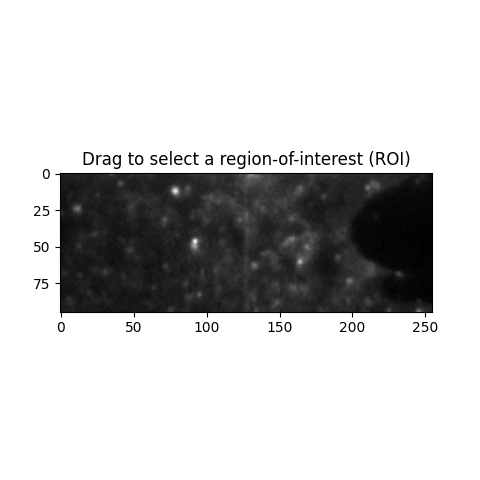

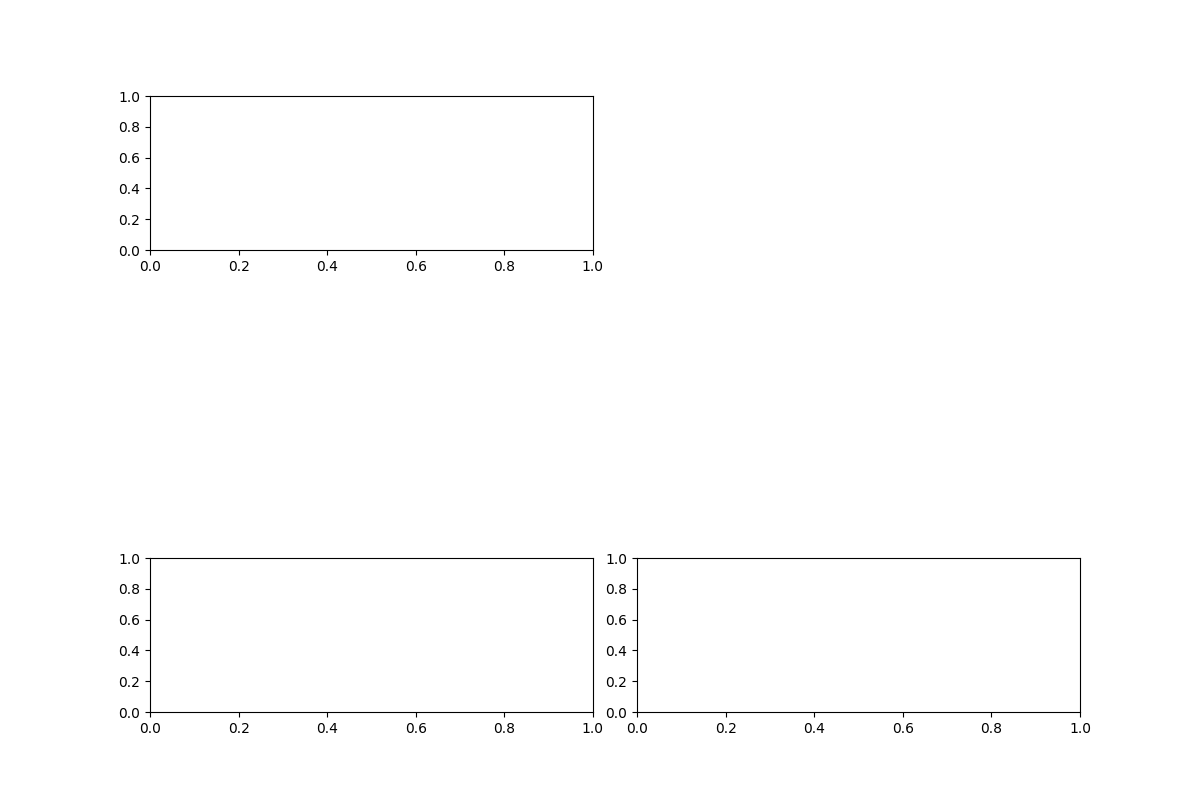

In [7]:
%matplotlib widget
# Create and run the app
app = ImfcsScreenerApp(input_path=input_path, loaded_database=all_image_instance)
app.run()

### Choose whether to save/resave databse


In [8]:
IS_SAVE_DB = False

if IS_SAVE_DB:
    if IS_LOAD_FROM_PICKLE:
        print(
            f"overwriting {PICKLE_DATABSE_FILENAME} saving database array as pickle..."
        )
    else:
        print(f"saving database array as pickle... {PICKLE_DATABSE_FILENAME}")

    # get database
    all_image_instance = app.get_AllImage()

    # Saving to pickle
    all_image_instance.save(
        filename=Path(os.path.join(input_path, PICKLE_DATABSE_FILENAME))
    )